# 11 · Auditory and visual evoked responses

**ROBT613 · Brain–Computer Interfaces** | 90–120 min

## Goal
Explore a different event-related paradigm, compare EEG responses to auditory and visual stimuli and distinguish sensory decoding from intentional BCI control.

**Data:** MNE sample auditory/visual EEG; large optional download

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

An evoked response is time-locked to an event and phase-consistent enough to survive averaging. Induced activity can change power without a consistent phase, disappearing in the ERP while remaining in a time-frequency analysis.

For condition means $\bar X_A,\bar X_V$, a contrast is $D=\bar X_A-\bar X_V$. A contrast plot does not by itself establish statistical significance: channels and time samples are correlated and exploratory testing involves multiplicity. The standard error $s(t)/\sqrt{N}$ assumes independent observations; correlated trials and shared artifacts weaken that assumption.

MNE’s sample dataset contains auditory and visual events recorded with MEG and EEG. We use EEG only to keep the lesson CPU-friendly. This is **not** an auditory P300 speller, and decoding stimulus modality is not equivalent to decoding a user’s intention. To design an auditory BCI, add a task requiring selective attention and explicit target metadata.

## Load the sample recording
The native archive is large: budget roughly 2 GB disk plus extraction space. Download once before class.

In [2]:
path=mne.datasets.sample.data_path(path=DATA_ROOT,update_path=False)
raw=mne.io.read_raw_fif(path/'MEG'/'sample'/'sample_audvis_raw.fif',preload=False)
events=mne.find_events(raw,stim_channel='STI 014')
raw.pick(['eeg','eog']).load_data()
raw.set_eeg_reference('average',projection=False)
raw.filter(.5,30)
epochs=mne.Epochs(raw,events,{'auditory/left':1,'auditory/right':2,
                            'visual/left':3,'visual/right':4},-.2,.6,
                  baseline=(-.2,0),reject={'eeg':150e-6,'eog':250e-6},preload=True)
print({name:len(epochs[name]) for name in ['auditory','visual']})

{'auditory': 136, 'visual': 139}


## Compare evoked responses
A channel-average trace can cancel spatially opposed fields. Use the global field power (sensor standard deviation) to summarize response magnitude.

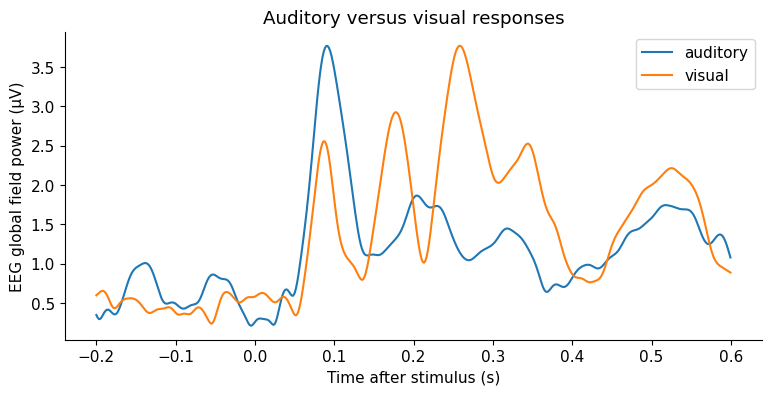

Rejected fraction: 0.04844290657439443


In [3]:
fig,ax=plt.subplots()
for condition in ['auditory','visual']:
    evoked=epochs[condition].average(picks='eeg')
    gfp=evoked.data.std(axis=0)*1e6
    ax.plot(evoked.times,gfp,label=condition)
ax.set(xlabel='Time after stimulus (s)',ylabel='EEG global field power (µV)',title='Auditory versus visual responses')
ax.legend(); plt.show()
print('Rejected fraction:',1-len(epochs)/sum(np.isin(events[:,2],[1,2,3,4])))

## Exercises and checks
1. Compare left/right auditory stimulation and describe what is measured.
2. Propose an auditory oddball design with standards and attended deviants.
3. Explain the experimental changes needed for an error-related potential (ErrP) correction BCI.
4. Why should feedback-locked ErrP epochs not be treated as stimulus-locked P300 epochs?

## Next steps and sources
[MNE sample dataset](https://mne.tools/stable/documentation/datasets.html#sample) · [ERP analysis](https://mne.tools/stable/auto_tutorials/evoked/30_eeg_erp.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.